# Two contrasts, one ratio, and no bias field

[`01_build.ipynb`](01_build.ipynb) wrote one `.seq` file containing two contrasts, distinguished
only by a `SET` label. This notebook reads that label **back out of the file**, splits the data
by it, and combines the two images:

$$\mathrm{UNI} = \frac{\mathrm{Re}\left(S_1 \, S_2^{*}\right)}{|S_1|^2 + |S_2|^2}$$

Bounded on $[-0.5, 0.5]$, and the reason MP2RAGE exists: the receive field and the proton density
appear in **both** images and cancel in the ratio, leaving something close to a pure T1 contrast
with no shading.

Reading `SET` back rather than reconstructing the ordering is also what makes the label
load-bearing instead of decorative — a mislabelled second shot would put half of TI₁'s lines into
the TI₂ image, and the two reconstructions would come out as a blend rather than as two
contrasts.

**Needs `seqcraft[sim]`** — MRzeroCore and torch — and the same BrainWeb phantom the other
examples download into `examples/data/`. No `sigpy` here: §3 explains why the coil combination
this notebook needs is not the one ESPIRiT provides.

In [1]:
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

plt.rcParams['figure.dpi'] = 56

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'mp2rage_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
CENTER_LINE = int(nominal['center_line'])
TI_S = tuple(float(v) for v in nominal['ti_s'])
FLIP_DEG = tuple(float(v) for v in nominal['flip_deg'])
TURBO = int(nominal['turbo'])
NX, NY = MATRIX
SEQ = SEQ_DIR / 'mp2rage_2d.seq'

opts = pp.Opts(max_grad=40, grad_unit='mT/m', max_slew=150, slew_unit='T/m/s', B0=3.0,
               rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6)

print(f'{NX} x {NY}, TI = {TI_S[0] * 1e3:.0f} and {TI_S[1] * 1e3:.0f} ms, '
      f'flips {FLIP_DEG[0]:.0f} and {FLIP_DEG[1]:.0f} deg  ->  {SEQ}')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128, TI = 700 and 2200 ms, flips 4 and 5 deg  ->  seq\mp2rage_2d.seq


## 1. The phantom, and why the ring array is not optional here

The same BrainWeb slab and eight-element receive ring as the other two examples. In `gre_2d/02`
the array was there so that an undersampled trajectory had more measurements than unknowns.
**Here it is the thing being demonstrated**: if the sensitivities were uniform there would be no
bias field to cancel and the figure at the end would show nothing.

In [2]:
PHANTOM_URL = ('https://github.com/MRsources/MRzero-Core/raw/main/'
               'documentation/playground_mr0/subject05.npz')
PHANTOM = Path('../data/subject05.npz')
if not PHANTOM.exists():
    PHANTOM.parent.mkdir(parents=True, exist_ok=True)
    print(f'downloading {PHANTOM_URL} -> {PHANTOM} (~19 MB, once)')
    urllib.request.urlretrieve(PHANTOM_URL, PHANTOM)

NZ, N_COILS = 4, 8


def coil_ring(nx, ny, nz, n_coils=N_COILS):
    """A ring of `n_coils` surface coils around the object, as complex sensitivities."""
    gx, gy = np.meshgrid(np.linspace(-1, 1, nx), np.linspace(-1, 1, ny), indexing='ij')
    sens = np.stack([
        np.exp(-((gx - 1.5 * np.cos(a)) ** 2 + (gy - 1.5 * np.sin(a)) ** 2) / 1.5)
        * np.exp(1j * np.arctan2(gy - np.sin(a), gx - np.cos(a)))
        for a in np.arange(n_coils) * 2 * np.pi / n_coils
    ]).astype(np.complex64)
    return torch.tensor(np.repeat(sens[:, :, :, None], nz, axis=3))


whole = mr0.VoxelGridPhantom.load(PHANTOM).interpolate(NX, NX, 128)
phantom = whole.slices(list(range(64 - NZ // 2, 64 + NZ - NZ // 2)))
phantom.affine[2, 3] = -0.5 * NZ * float(phantom.affine[2, 2])
phantom.coil_sens = coil_ring(NX, NX, NZ)
data = phantom.build()

mid = NZ // 2
t1_map = phantom.T1[:, :, mid].numpy().T
brain = t1_map > 0.2
coil_profile = np.sqrt((np.abs(phantom.coil_sens[:, :, :, mid].numpy()) ** 2).sum(0)).T

print(f'{tuple(phantom.PD.shape)} voxels, {N_COILS} coils')
print(f'coil root-sum-of-squares varies {coil_profile[brain].min():.2f} .. '
      f'{coil_profile[brain].max():.2f} across the object -- a factor of '
      f'{coil_profile[brain].max() / coil_profile[brain].min():.1f}')
print(f'the two TIs null T1 = {TI_S[0] / np.log(2):.2f} s and '
      f'{TI_S[1] / np.log(2):.2f} s')

(128, 128, 4) voxels, 8 coils
coil root-sum-of-squares varies 0.63 .. 1.08 across the object -- a factor of 1.7
the two TIs null T1 = 1.01 s and 3.17 s


## 2. Simulate once, split by the label

One simulation of one file. The split is by the `SET` values **parsed back out of the written
`.seq`**, beside the `LIN` values that say which k-space row each readout belongs to. Neither is
taken from the notebook's own segmentation: the file is the record, and a disagreement between
the two is exactly the failure worth catching.

In [3]:
seq = mr0.Sequence.import_file(str(SEQ))
signal = np.asarray(mr0.execute_graph(
    mr0.compute_graph(seq, data, max_state_count=200, min_state_mag=1e-4),
    seq, data, min_emitted_signal=1e-4, min_latent_signal=1e-5, print_progress=False))

written = pp.Sequence(system=opts)
written.read(str(SEQ))
labels = written.evaluate_labels(evolution='adc')
lin = np.asarray(labels['LIN']).astype(int)
sets = np.asarray(labels['SET']).astype(int)

samples = signal.reshape(len(lin), NX, -1)                      # (readout, sample, coil)
ksp = np.zeros((2, samples.shape[2], NY, NX), dtype=np.complex64)
for contrast in (0, 1):
    rows = sets == contrast
    ksp[contrast][:, lin[rows], :] = samples[rows].transpose(2, 0, 1)

assert len(lin) == 2 * NY
assert sorted(np.bincount(sets).tolist()) == [NY, NY]
for contrast in (0, 1):
    assert sorted(lin[sets == contrast].tolist()) == list(range(NY)), 'a contrast is incomplete'

print(f'{len(lin)} readouts -> two full {NY} x {NX} k-spaces, split by SET')
print(f'SET=0 first eight LIN {lin[sets == 0][:8].tolist()}')
print(f'SET=1 first eight LIN {lin[sets == 1][:8].tolist()}')

256 readouts -> two full 128 x 128 k-spaces, split by SET
SET=0 first eight LIN [64, 60, 68, 56, 72, 52, 76, 48]
SET=1 first eight LIN [64, 60, 68, 56, 72, 52, 76, 48]


## 3. The combination, and the coil algebra that makes it work

The receive field cancels **exactly, per coil, before any coil combination**. Writing $S_{ic}$ for
contrast $i$ on coil $c$, with $m_i$ the underlying magnetisation and $C_c$ the sensitivity:

$$S_{1c} S_{2c}^{*} = |C_c|^2\, m_1 m_2^{*}, \qquad
  |S_{1c}|^2 + |S_{2c}|^2 = |C_c|^2 \left(|m_1|^2 + |m_2|^2\right)$$

so $|C_c|^2$ divides out of the ratio. Summing the numerator and the denominator over coils
*before* dividing is therefore both the optimal combination and an exact one:

```python
UNI = sum_c Re(S1c · conj(S2c)) / sum_c (|S1c|² + |S2c|²)
```

This is why no ESPIRiT appears in this notebook. A sensitivity estimate would be one more thing
to be wrong, and the algebra above needs none — which is a stronger statement than "the bias is
small". A root-sum-of-squares magnitude image, by contrast, keeps $|C_c|$ in full, and §4 is that
comparison.

In [4]:
def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)),
                                        norm='ortho'), axes=(-2, -1))


images = ifft2c(ksp)                                            # (contrast, coil, ny, nx)
rss = np.sqrt((np.abs(images) ** 2).sum(1))                     # (contrast, ny, nx)

numerator = np.real(images[0] * np.conj(images[1])).sum(0)
denominator = (np.abs(images[0]) ** 2 + np.abs(images[1]) ** 2).sum(0)
uni = numerator / np.maximum(denominator, 1e-30)

assert uni.min() >= -0.5 - 1e-9 and uni.max() <= 0.5 + 1e-9, (uni.min(), uni.max())
print(f'UNI spans {uni.min():+.4f} .. {uni.max():+.4f}, inside [-0.5, +0.5]')
print('Outside that range would mean a conjugate in the wrong place: the bound is not a')
print('convention, it is |Re(ab*)| <= (|a|^2 + |b|^2)/2 with equality when |a| = |b|.')

UNI spans -0.5000 .. +0.4975, inside [-0.5, +0.5]
Outside that range would mean a conjugate in the wrong place: the bound is not a
convention, it is |Re(ab*)| <= (|a|^2 + |b|^2)/2 with equality when |a| = |b|.


## 4. The bias field, and its absence

The decisive test is not a picture, it is **the same file simulated twice**: once against the
eight-element ring and once against a single uniform coil. If `UNI` is free of the receive field
then it must come out *the same both times*, while the magnitude images must not.

A comparison of bright and dark regions within one image would not settle it, because the coil
profile and the anatomy vary together — the cortex is both at the edge of the array and a
different tissue from the core. Changing only the array holds the anatomy fixed.

In [5]:
def simulate_with(coil_sens):
    """The same written file and the same phantom, with a different receive array."""
    phantom.coil_sens = coil_sens
    payload = phantom.build()
    raw = np.asarray(mr0.execute_graph(
        mr0.compute_graph(seq, payload, max_state_count=200, min_state_mag=1e-4),
        seq, payload, min_emitted_signal=1e-4, min_latent_signal=1e-5, print_progress=False))
    block = raw.reshape(len(lin), NX, -1)
    grids = np.zeros((2, block.shape[2], NY, NX), dtype=np.complex64)
    for contrast in (0, 1):
        rows = sets == contrast
        grids[contrast][:, lin[rows], :] = block[rows].transpose(2, 0, 1)
    return ifft2c(grids)


def combine(coil_images):
    """UNI, summed over coils before the division -- see the algebra above."""
    top = np.real(coil_images[0] * np.conj(coil_images[1])).sum(0)
    bottom = (np.abs(coil_images[0]) ** 2 + np.abs(coil_images[1]) ** 2).sum(0)
    return top / np.maximum(bottom, 1e-30)


mask = brain
flat_images = simulate_with(torch.ones((1, NX, NX, NZ), dtype=torch.complex64))
phantom.coil_sens = coil_ring(NX, NX, NZ)          # put the ring back

flat_rss = np.sqrt((np.abs(flat_images) ** 2).sum(1))
flat_uni = combine(flat_images)


def shading(a, b, region):
    """
    How much of `a` is a smooth multiplicative shading relative to `b`.

    A bias field is a *ratio*, so this reports the spread of ``a / b`` across the object with its
    median divided out.  For a magnitude image against the same image under a different array,
    that ratio is the coil profile.
    """
    ratio = a[region] / np.where(np.abs(b[region]) > 1e-9, b[region], np.nan)
    ratio = ratio / np.nanmedian(ratio)
    low, high = np.nanpercentile(ratio, [5, 95])
    return high / low


def spread(a, b, region, full_range):
    """Mean absolute difference between `a` and `b`, in units of the quantity's own range."""
    return float(np.abs(a[region] - b[region]).mean() / full_range)


print(f'{"":22s} {"5-95 % shading":>16s} {"mean |difference|":>19s}')
for contrast in (0, 1):
    magnitude_range = float(np.percentile(rss[contrast][mask], 95))
    print(f'|S| at TI{contrast:<12d} '
          f'{shading(rss[contrast], flat_rss[contrast], mask):15.2f}x '
          f'{100 * spread(rss[contrast] / rss[contrast][mask].mean(), flat_rss[contrast] / flat_rss[contrast][mask].mean(), mask, 1.0):18.1f} %')
print(f'{"UNI":22s} {"--":>16s} '
      f'{100 * spread(uni, flat_uni, mask, 1.0):18.1f} %')
print()
print('A bias field is a *ratio*, so the magnitudes are compared by one: swapping the array')
print('changes them by a smooth factor of several across the object.  UNI has no such ratio to')
print('report -- it crosses zero -- so it is compared by absolute difference against its own')
print('range of 1.0, and what is left is a small residue at edges rather than shading.')
print()
# A bias field is smooth, so if any survived in UNI it would correlate with the coil profile.
residue = (uni - flat_uni)[mask]
profile = coil_profile[mask] - coil_profile[mask].mean()
correlation = float((residue - residue.mean()) @ profile
                    / np.sqrt(((residue - residue.mean()) ** 2).sum() * (profile ** 2).sum()))
print(f'correlation between the UNI residue and the coil profile: {correlation:+.3f}')
print('Near zero: whatever is left is not the receive field.')

                         5-95 % shading   mean |difference|
|S| at TI0                       1.86x               11.7 %
|S| at TI1                       1.75x               11.5 %
UNI                                  --                1.6 %

A bias field is a *ratio*, so the magnitudes are compared by one: swapping the array
changes them by a smooth factor of several across the object.  UNI has no such ratio to
report -- it crosses zero -- so it is compared by absolute difference against its own
range of 1.0, and what is left is a small residue at edges rather than shading.

correlation between the UNI residue and the coil profile: -0.085
Near zero: whatever is left is not the receive field.


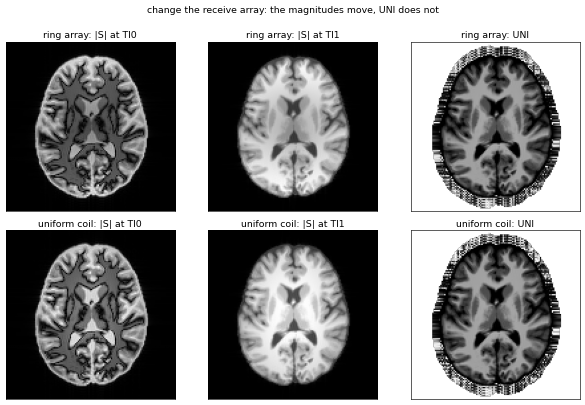

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7.2))
for row, (label, magnitudes, combined) in enumerate((
        ('ring array', rss, uni), ('uniform coil', flat_rss, flat_uni))):
    for column, contrast in enumerate((0, 1)):
        axes[row, column].imshow(magnitudes[contrast], origin='lower', cmap='gray')
        axes[row, column].set(title=f'{label}: |S| at TI{contrast}', xticks=[], yticks=[])
    axes[row, 2].imshow(np.where(mask, combined, np.nan), origin='lower', cmap='gray',
                        vmin=-0.5, vmax=0.5)
    axes[row, 2].set(title=f'{label}: UNI', xticks=[], yticks=[])
fig.suptitle('change the receive array: the magnitudes move, UNI does not', y=1.0)
fig.tight_layout()

## 5. Is it a T1 map?

`UNI` has to be **monotonic in T1** to be usable as a lookup, and it is — over a window rather
than everywhere. What bounds the window is not either null point but the two T1s at which
$|S_1| = |S_2|$: there $\mathrm{Re}(S_1S_2^*) = \mp\tfrac12(|S_1|^2+|S_2|^2)$, so `UNI` reaches
$\mp 0.5$ and turns back. Outside that window two different T1s give the same value.

This is a property of MP2RAGE and of the pair of TIs chosen, not a fault in the sequence, and it
is why the analytic lookup is always quoted with a validity range. Widening the window means a
longer second TI, which means a longer shot interval and a longer scan — the efficiency trade
this example deliberately does not chase.

The measurement below finds the window rather than predicting it: the longest decreasing run of
the median-per-T1-bin curve, from the short-T1 end.

`UNI` is not linear in T1 and is not meant to be. The analytic lookup depends on the flip
angles, the TR and the train length as well, and inverting it is analysis rather than sequence.

median UNI over 22 T1 bins, 0.85 .. 2.95 s
minimum -0.369 at T1 = 2.75 s   <- where |S1| = |S2|
below it:  rank correlation with T1 = -0.826   (-1 is perfectly monotone decreasing)
above it:  rank correlation with T1 = +0.500   (the fold: the sign reverses)

The turn is at neither null (1.01 s and 3.17 s), because what bounds the window is |S1| = |S2| rather than
either image reaching zero.  White and grey matter sit inside it here; CSF at 4.2 s does
not, which is the usual MP2RAGE situation and the reason the lookup carries a range.


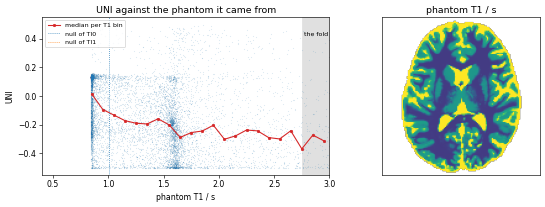

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(t1_map[mask].ravel(), uni[mask].ravel(), '.', ms=1.0, alpha=0.15)
edges = np.linspace(0.4, 3.0, 27)
centres = 0.5 * (edges[:-1] + edges[1:])
binned = np.array([
    np.median(uni[mask][(t1_map[mask] >= lo) & (t1_map[mask] < hi)])
    if ((t1_map[mask] >= lo) & (t1_map[mask] < hi)).sum() > 20 else np.nan
    for lo, hi in zip(edges[:-1], edges[1:])
])
ax[0].plot(centres, binned, 'C3.-', lw=1.4, label='median per T1 bin')
for contrast, ti in enumerate(TI_S):
    ax[0].axvline(ti / np.log(2), color=f'C{contrast}', ls=':', lw=1.0,
                  label=f'null of TI{contrast}')
ax[0].axvspan(centres[int(np.nanargmin(binned))], 3.0, color='0.88', zorder=0)
ax[0].text(0.5 * (centres[int(np.nanargmin(binned))] + 3.0), 0.42, 'the fold', ha='center',
           fontsize=8)

ax[0].set(xlabel='phantom T1 / s', ylabel='UNI', xlim=(0.4, 3.0), ylim=(-0.55, 0.55),
          title='UNI against the phantom it came from')
ax[0].legend(fontsize=8)

ax[1].imshow(np.where(mask, t1_map, np.nan), origin='lower', cmap='viridis', vmin=0.5, vmax=2.5)
ax[1].set(title='phantom T1 / s', xticks=[], yticks=[])
fig.tight_layout()

usable = ~np.isnan(binned)
curve, axis = binned[usable], centres[usable]

# Where the mapping turns is a measurement rather than a prediction: the minimum of the
# median-per-bin curve.  Below it, monotonicity is reported as a rank correlation, which is what
# a lookup actually needs -- a few dozen voxels per bin make a strict step-by-step test noisy
# without saying anything about whether the mapping is single-valued.
turn = int(np.argmin(curve))


def rank_correlation(a, b):
    """Spearman: Pearson on the ranks, which is monotonicity without assuming a shape."""
    ranks = [np.argsort(np.argsort(v)).astype(float) for v in (a, b)]
    centred = [r - r.mean() for r in ranks]
    return float(centred[0] @ centred[1]
                 / np.sqrt((centred[0] ** 2).sum() * (centred[1] ** 2).sum()))


print(f'median UNI over {len(curve)} T1 bins, {axis[0]:.2f} .. {axis[-1]:.2f} s')
print(f'minimum {curve[turn]:+.3f} at T1 = {axis[turn]:.2f} s   <- where |S1| = |S2|')
print(f'below it:  rank correlation with T1 = '
      f'{rank_correlation(axis[:turn + 1], curve[:turn + 1]):+.3f}   '
      f'(-1 is perfectly monotone decreasing)')
if turn + 1 < len(curve):
    print(f'above it:  rank correlation with T1 = '
          f'{rank_correlation(axis[turn:], curve[turn:]):+.3f}   '
          f'(the fold: the sign reverses)')
print()
print(f'The turn is at neither null ({TI_S[0] / np.log(2):.2f} s and '
      f'{TI_S[1] / np.log(2):.2f} s), because what bounds the window is |S1| = |S2| rather than')
print('either image reaching zero.  White and grey matter sit inside it here; CSF at 4.2 s does')
print('not, which is the usual MP2RAGE situation and the reason the lookup carries a range.')

---
## What this notebook established

| | |
|---|---|
| the two contrasts come out of **one file**, split by `SET` read back from it | and each half is a complete k-space, which is the assertion that a stateful-label bug would fail |
| the receive field cancels **per coil, before any combination** | $\|C_c\|^2$ divides out of $\mathrm{Re}(S_1S_2^*)/(\|S_1\|^2+\|S_2\|^2)$, so no sensitivity estimate is needed and none can be wrong |
| `UNI` is bounded on $[-0.5, 0.5]$ | not a convention: $\|\mathrm{Re}(ab^*)\| \le (\|a\|^2+\|b\|^2)/2$ |
| **the same file against two different arrays** moves the magnitudes and leaves `UNI` unchanged | a stronger statement than any single picture, because it holds the anatomy fixed and changes only the thing being cancelled |
| `UNI` is monotonic over a **window bounded by where** $\|S_1\| = \|S_2\|$, and folds beyond it | not at either null point, and measured rather than predicted; white and grey matter sit inside it, CSF does not |

What is **not** here, on purpose: T1 fitting from `UNI`, and any 3D variant. The first is
analysis rather than sequence; the second waits for `GRE3D`, which is where the ky–kz sampling
question has to be answered rather than deferred.